In [9]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
from omegaconf import OmegaConf


In [16]:
run_dir = Path("/scratch/mbuk/nmr/projects/01_shimator/shimnet/runs/multiscale/multiscale_600_input_and_loss")

config = OmegaConf.load(run_dir / "config.yaml")

train_losses = pd.read_csv(run_dir / "train.txt", sep='\s+', header=None, names=["BatchInStage", "Loss", "AvgLoss", "clean", "response", "noised", "multiscale_clean"])
for loss_name, loss_weight in config.losses_weights.items():
    if loss_weight > 0:
        train_losses[loss_name] *= loss_weight

<Axes: >

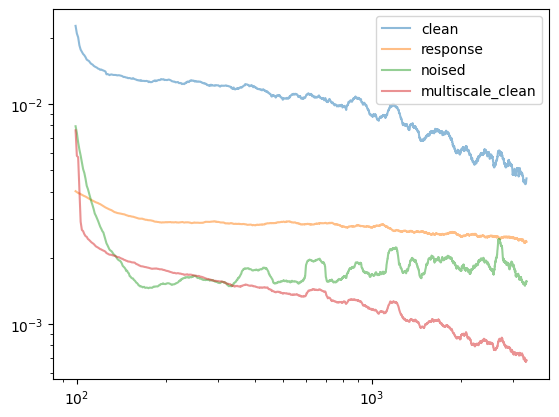

In [15]:
train_losses.rolling(window=100).mean().plot(y=["clean", "response", "noised", "multiscale_clean"], logy=True, logx=True, alpha=0.5)

In [17]:
from hydra.utils import instantiate

In [21]:
input_feature_extractor = instantiate(config.model.feature_extractor)
output_feature_extractor = instantiate(config.multiscale_output)

In [22]:
from shimnet.generators import get_datapipe

config.data.atom_groups_data_file = "../" + config.data.atom_groups_data_file
config.data.response_functions_files[0] = "../" + config.data.response_functions_files[0]

data_pipe = get_datapipe(**config.data, batch_size=16)
batch = next(iter(data_pipe))

/home/mbuk/miniconda3/envs/shimnetcpugui/lib/python3.10/site-packages/torchdata/datapipes/__init__.py:18: UserWarning: 
################################################################################
WARNING!
The 'datapipes', 'dataloader2' modules are deprecated and will be removed in a
future torchdata release! Please see https://github.com/pytorch/data/issues/1196
to learn more and leave feedback.
################################################################################

  deprecation_warning()


In [27]:
input_feature_extractor.concatenate_original

True

In [29]:
input_features = input_feature_extractor(batch["noised_spectrum"])
if input_feature_extractor.concatenate_original:
    input_features = input_features[:, 1:, :]
output_features = output_feature_extractor(batch["theoretical_spectrum"])
if output_feature_extractor.concatenate_original:
    output_features = output_features[:, 1:, :]

/tmp/ipykernel_2957562/1125133585.py:10: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(8,3.5))


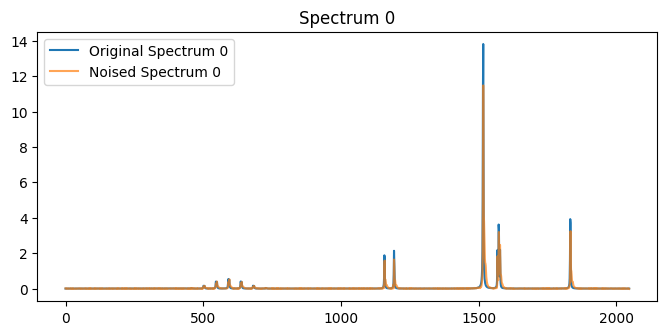

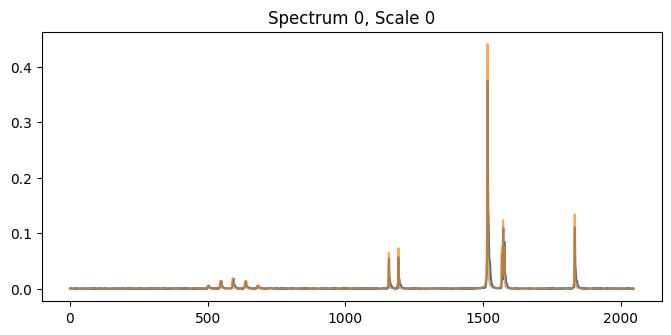

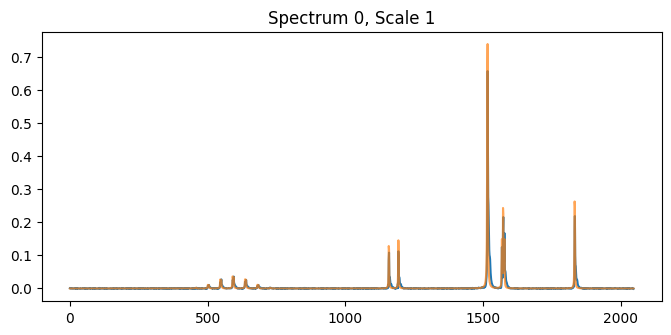

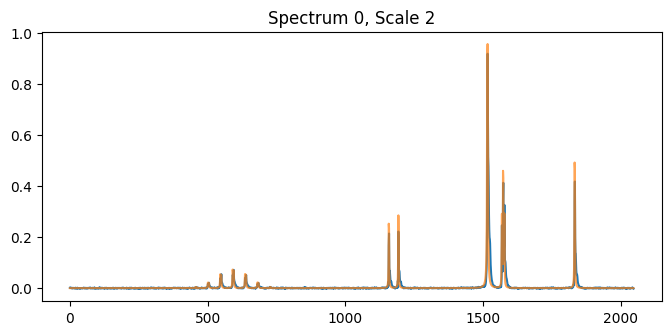

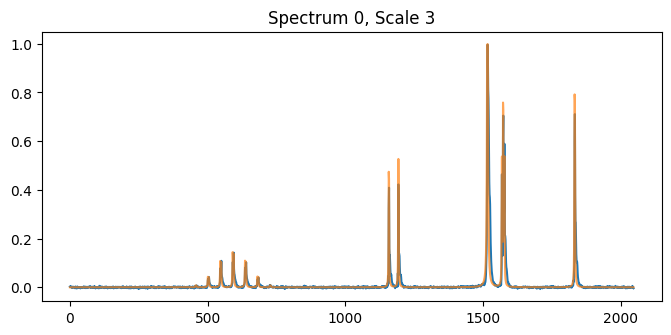

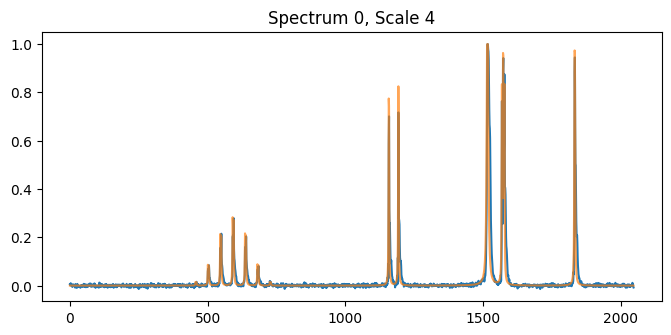

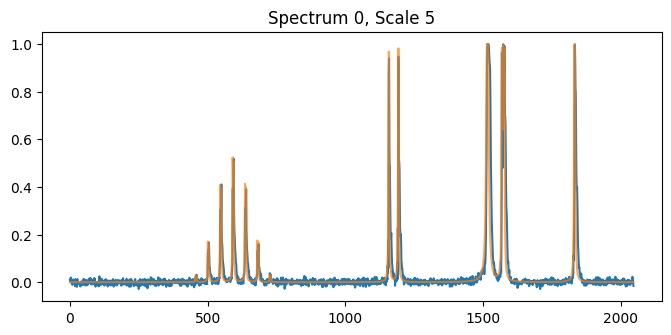

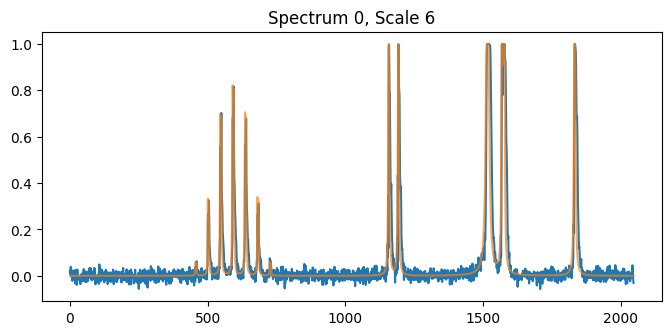

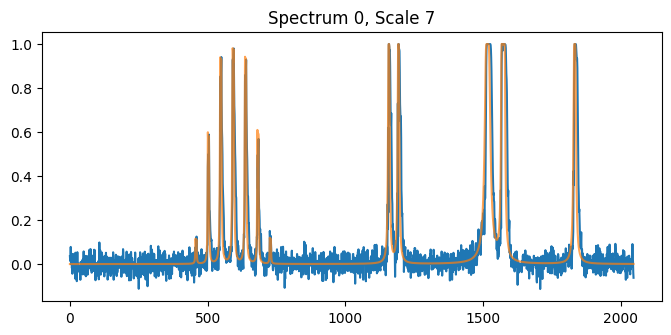

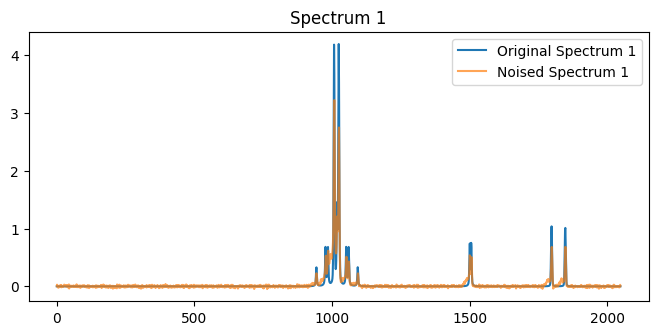

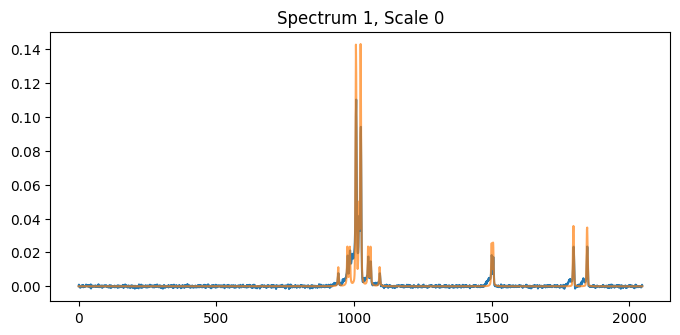

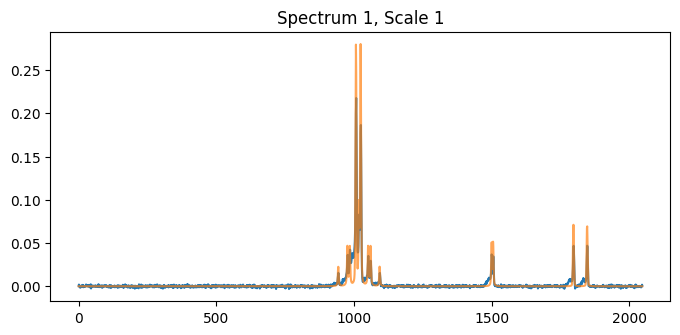

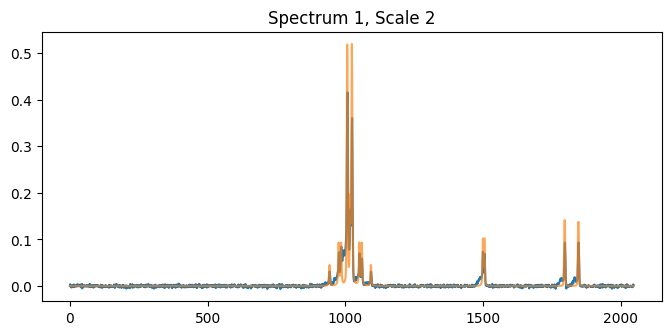

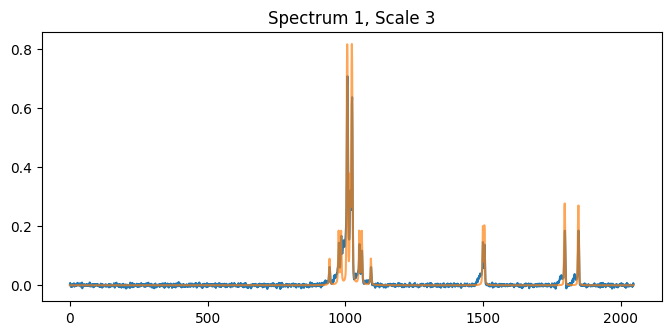

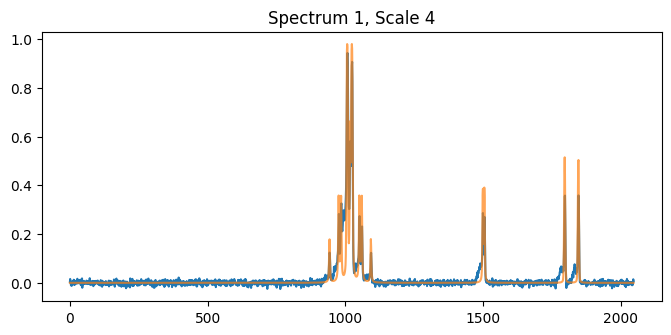

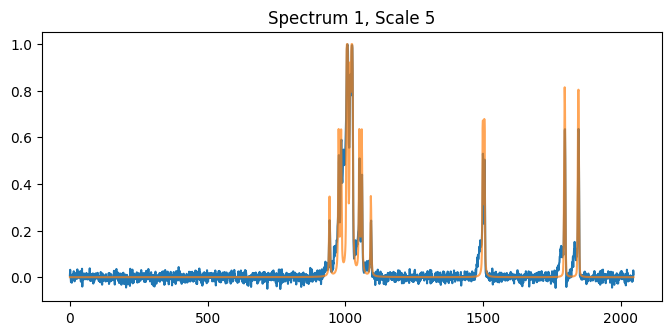

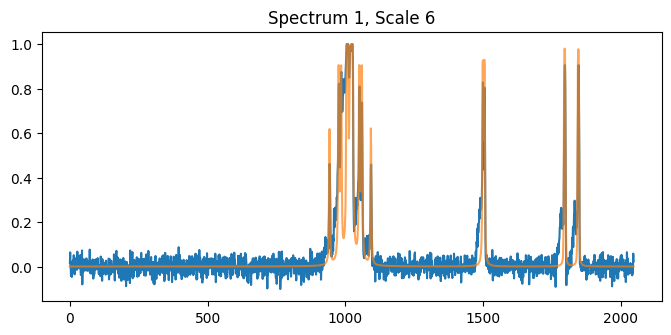

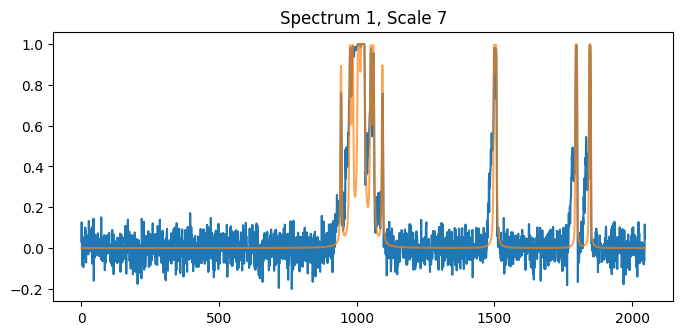

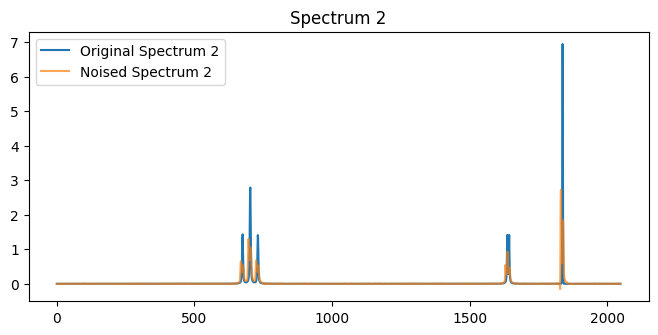

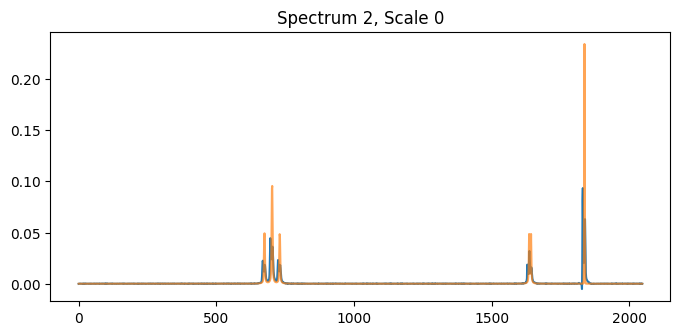

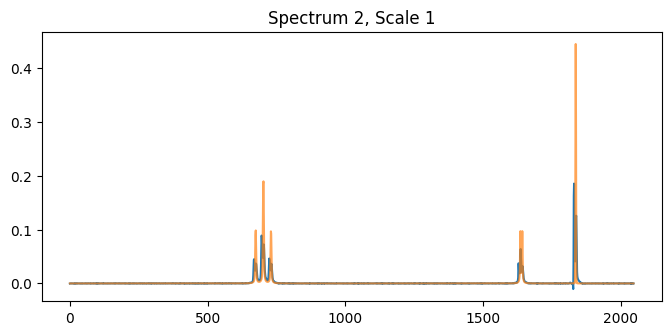

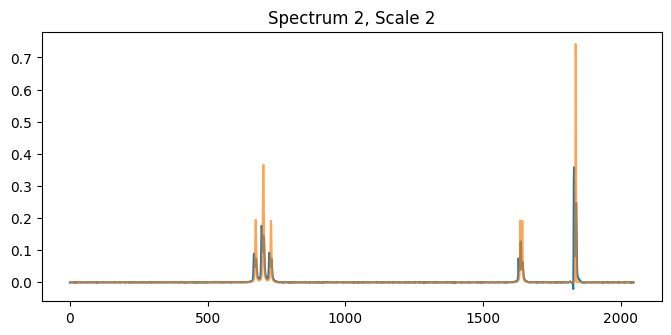

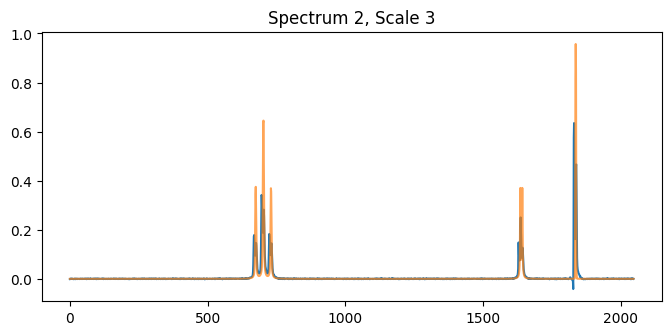

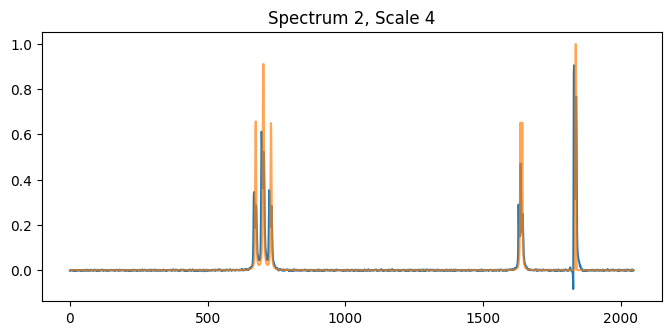

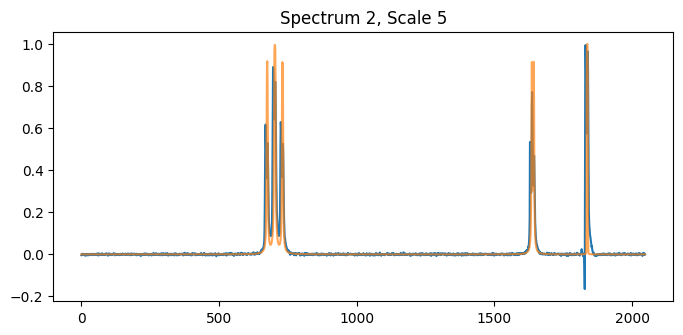

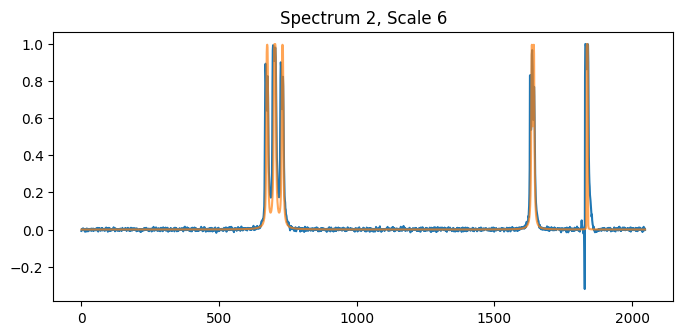

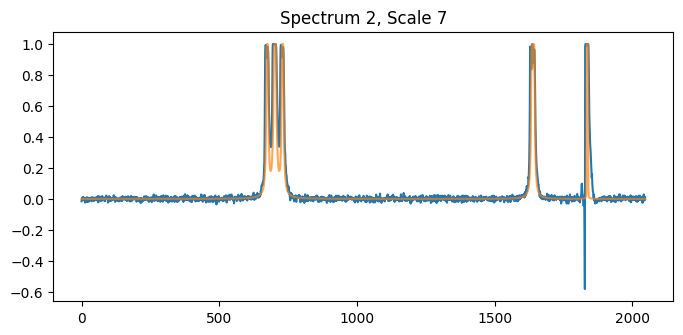

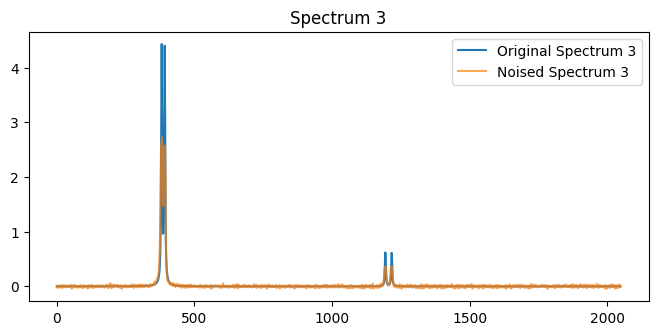

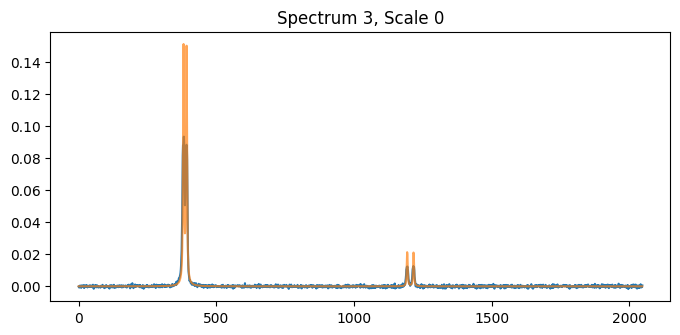

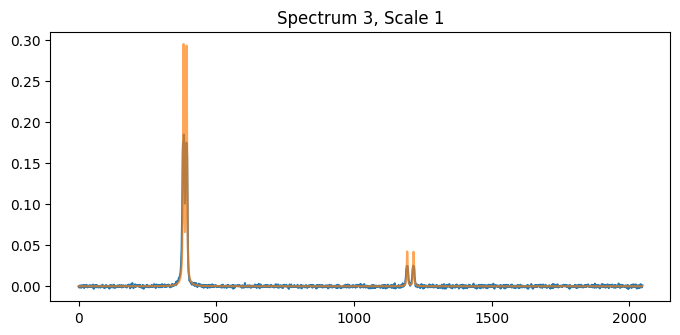

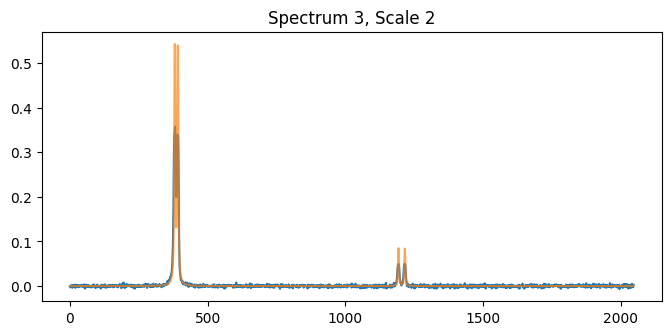

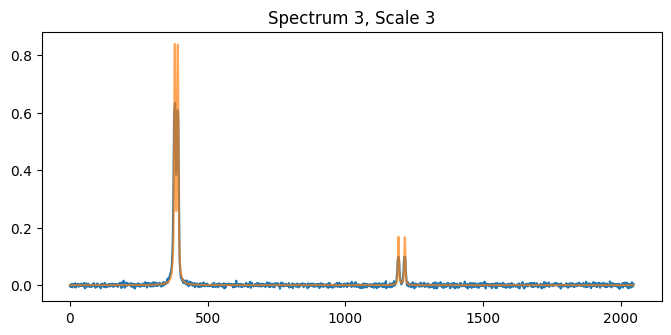

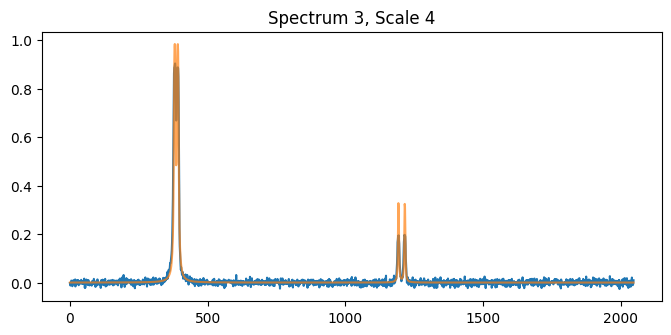

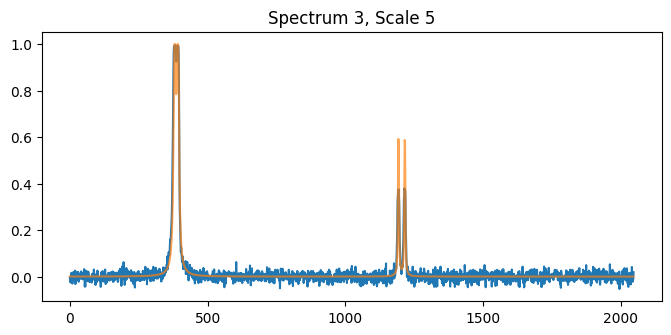

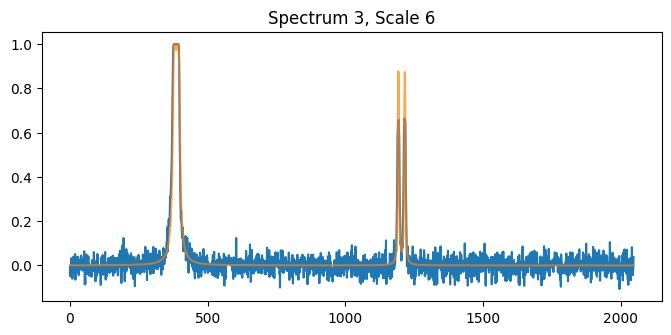

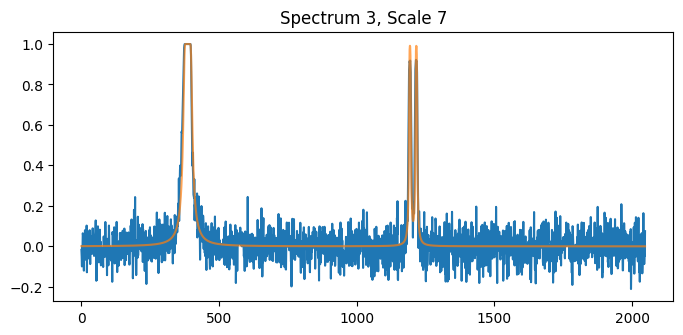

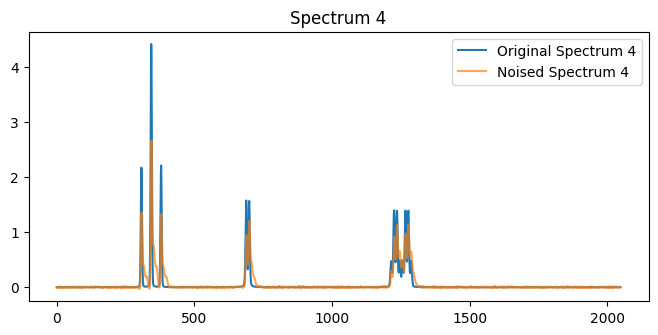

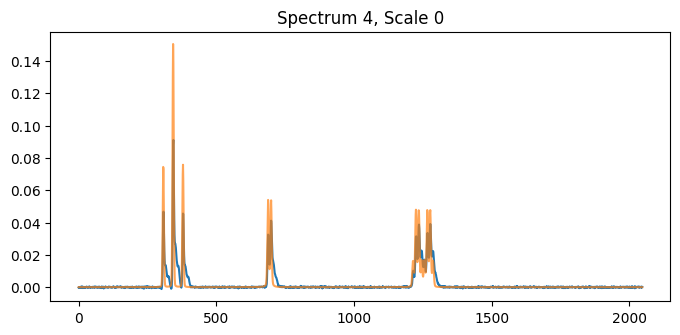

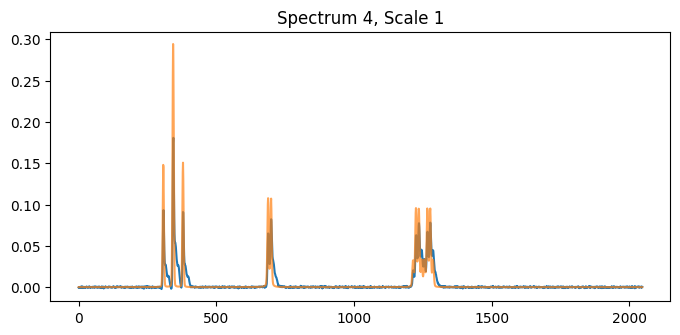

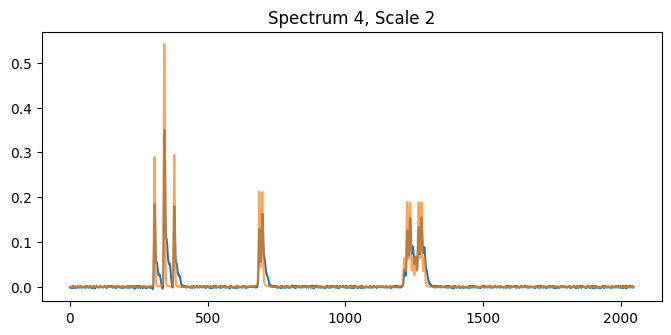

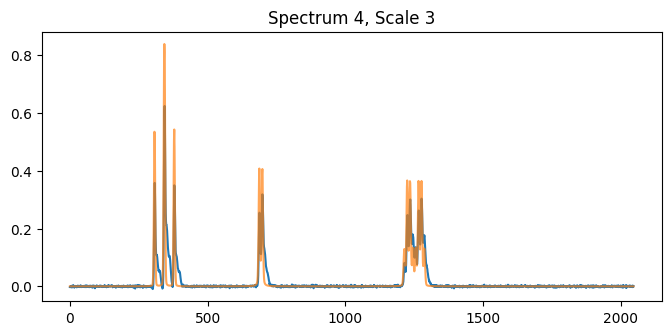

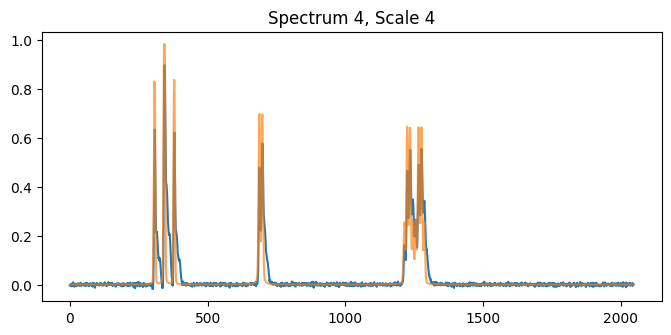

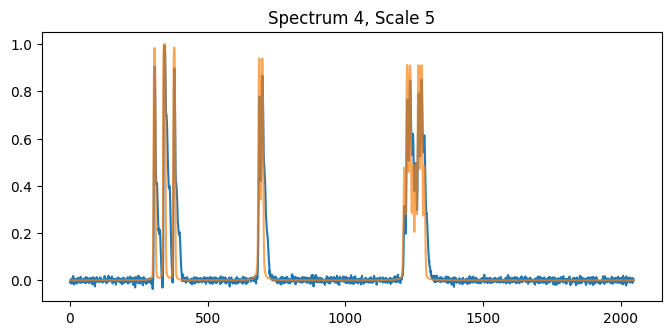

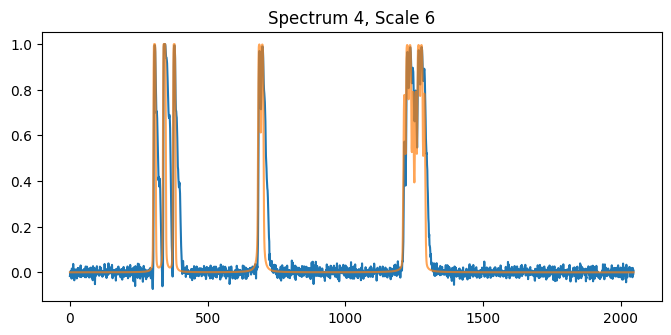

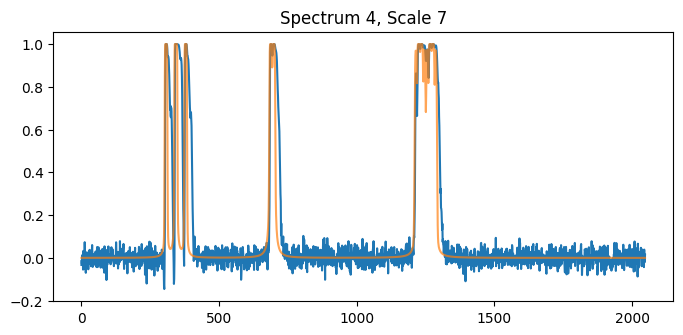

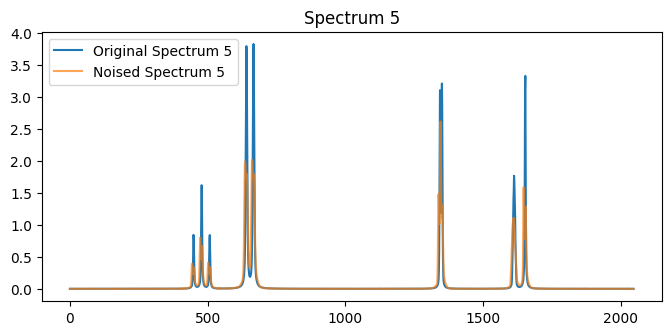

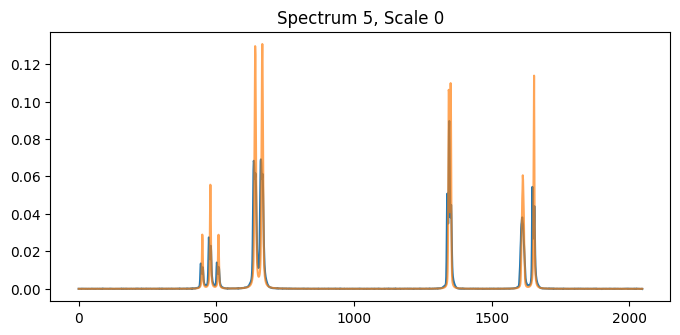

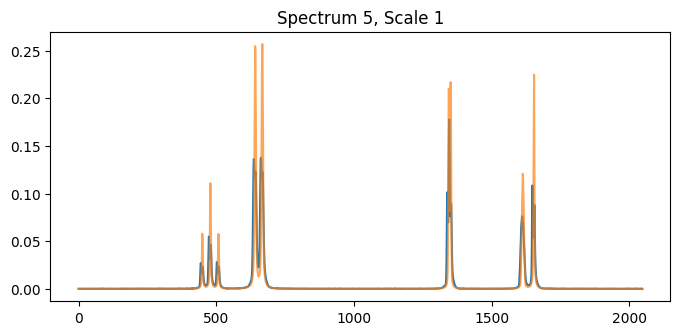

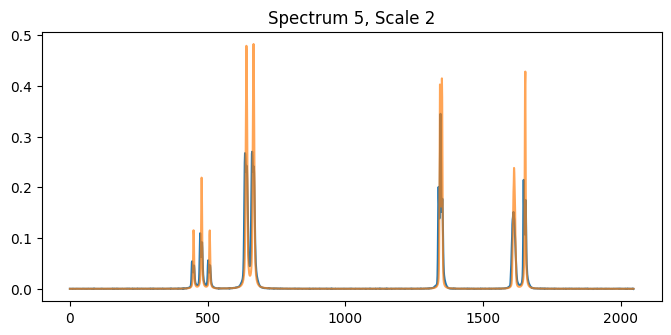

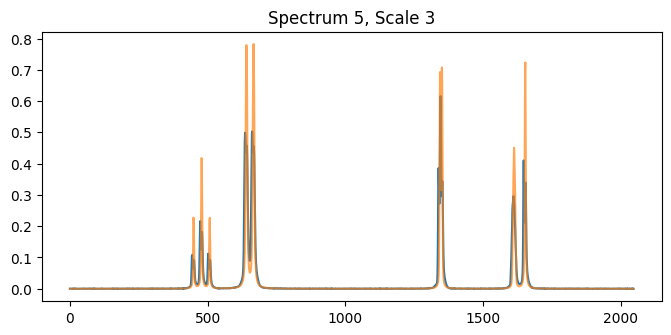

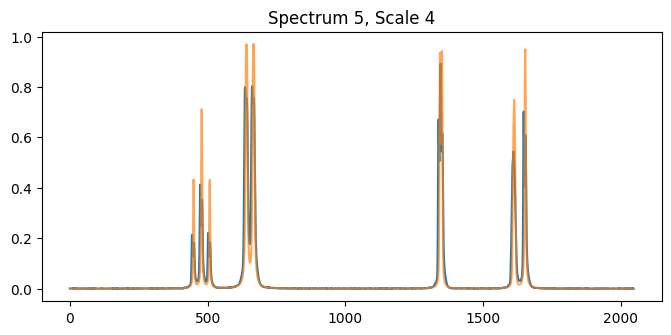

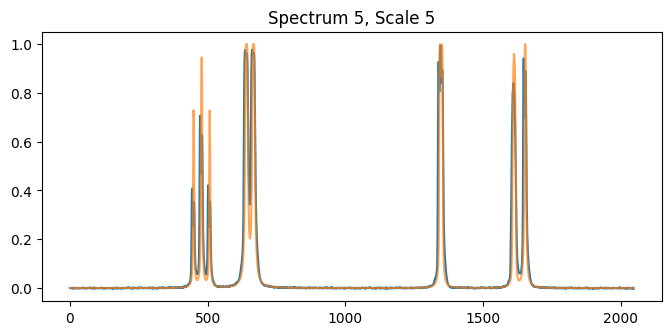

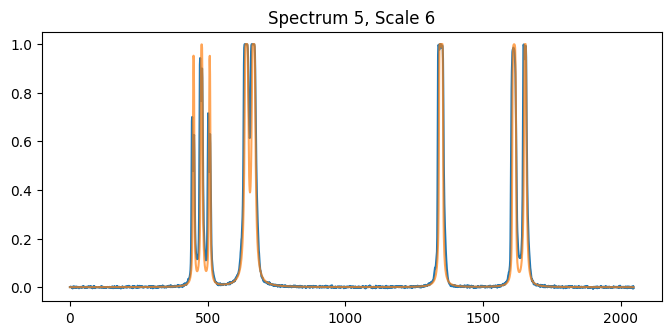

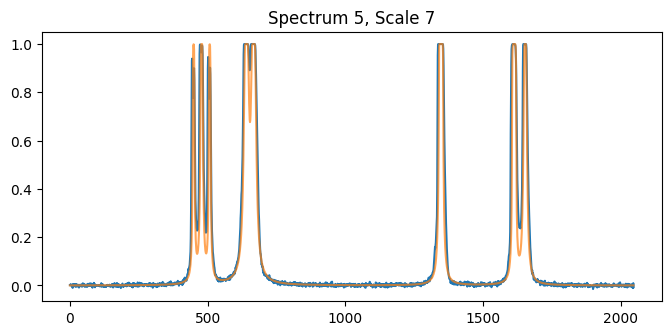

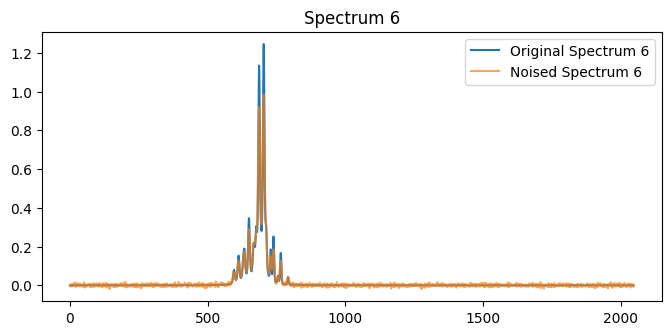

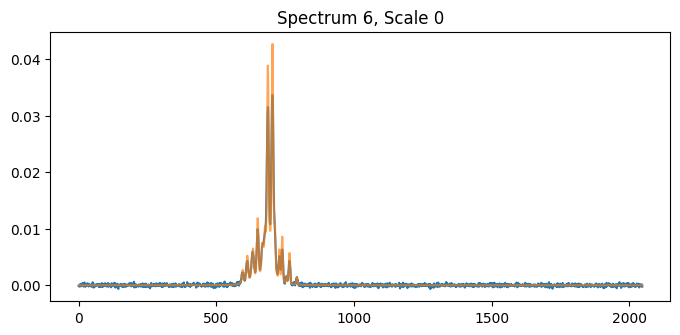

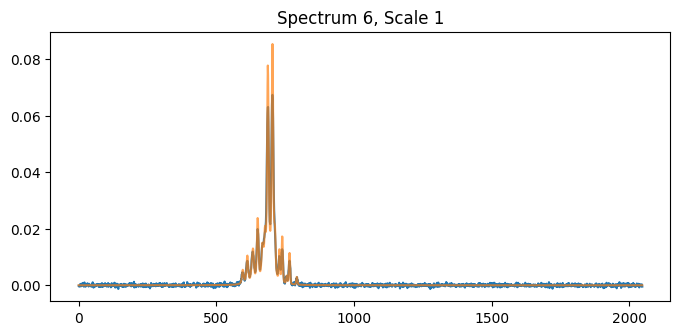

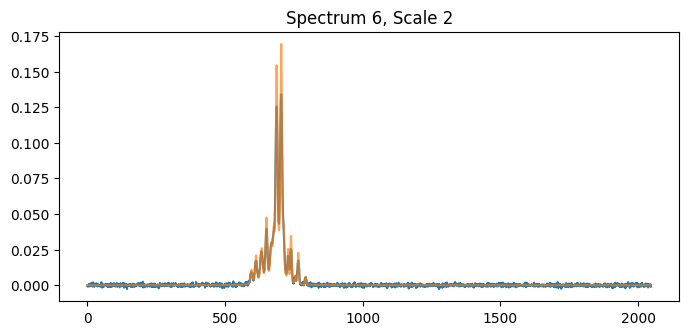

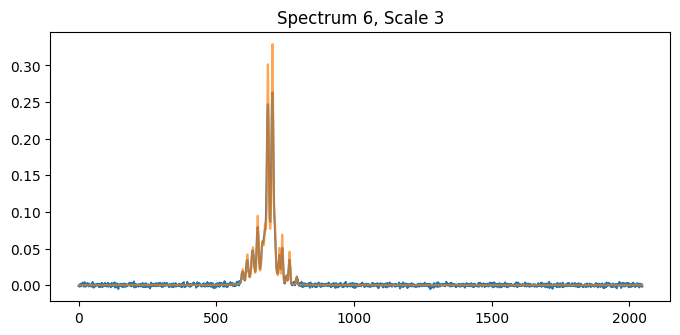

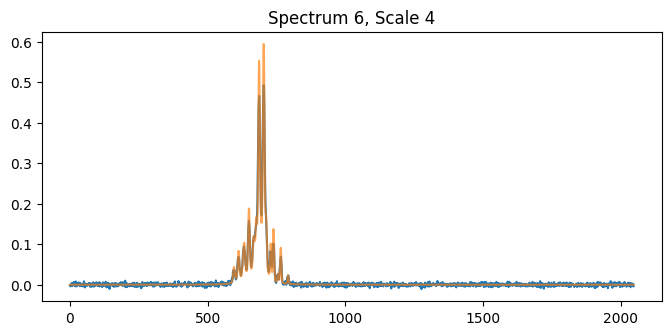

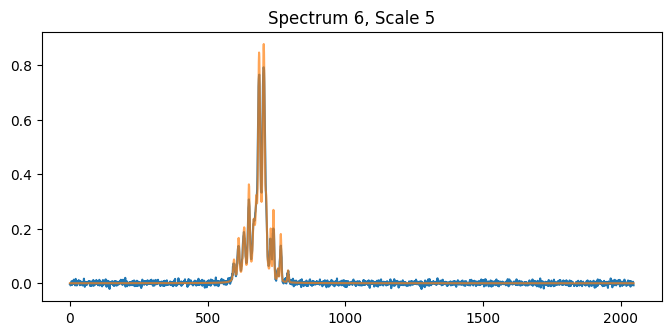

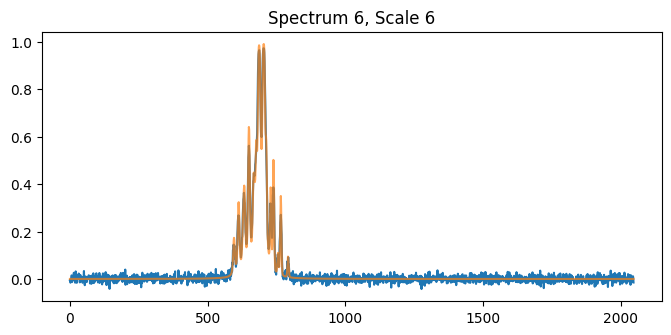

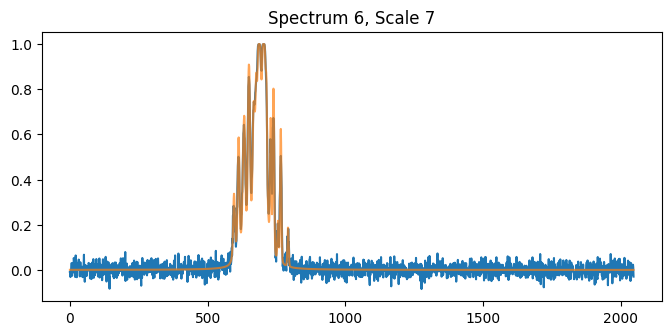

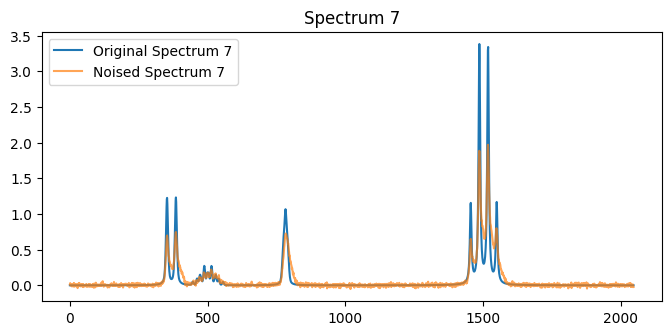

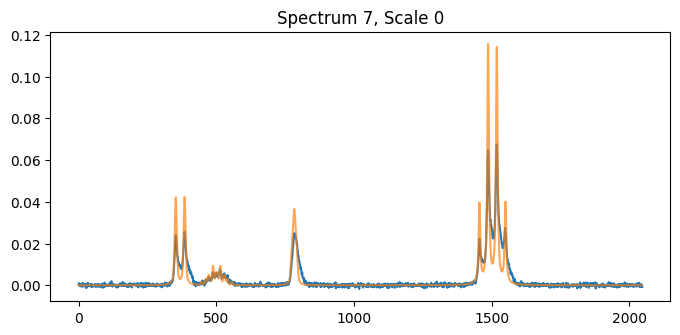

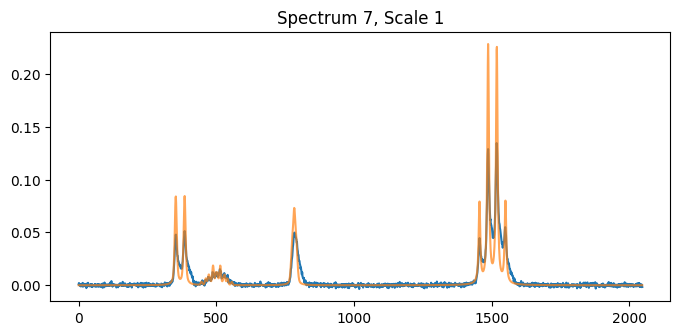

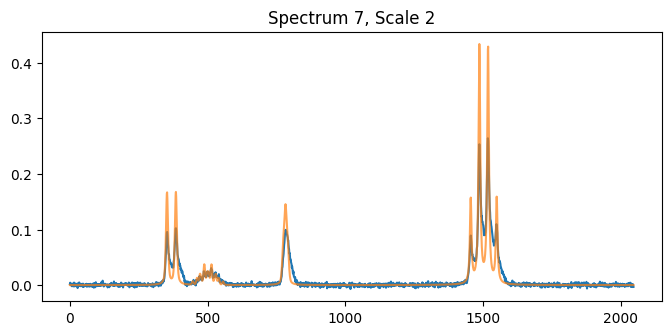

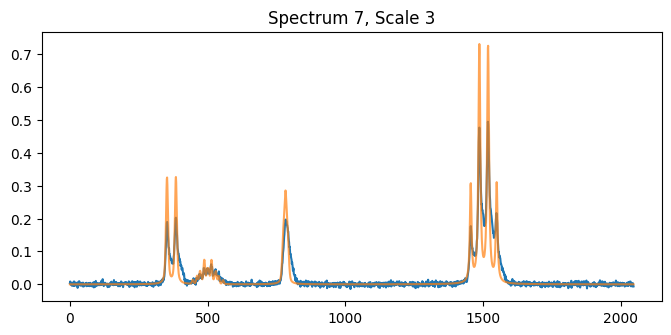

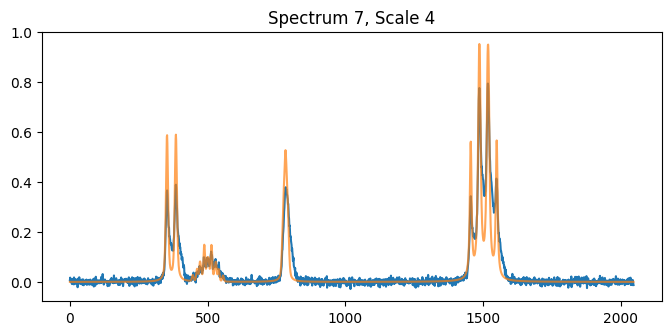

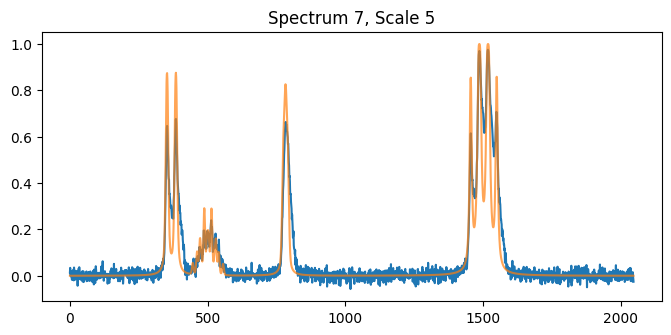

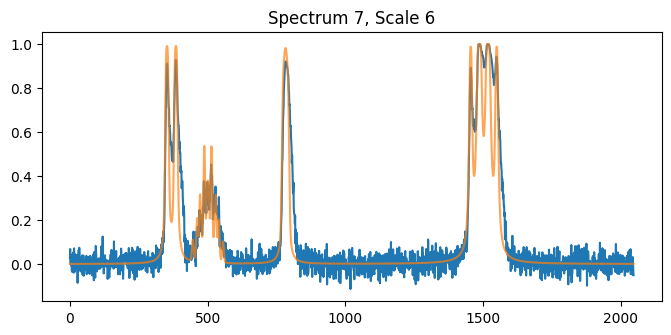

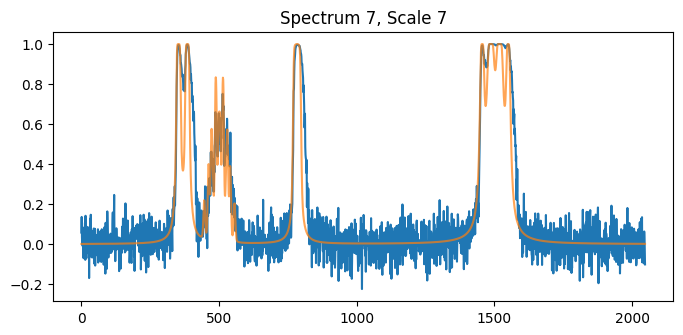

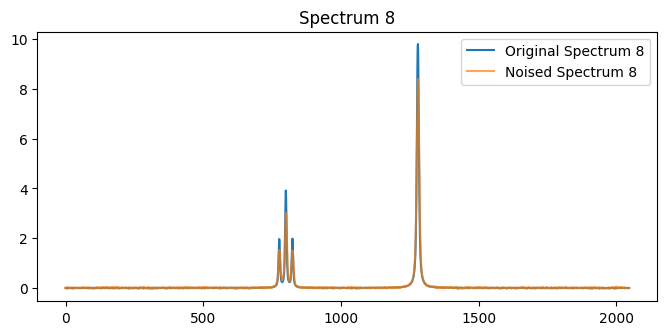

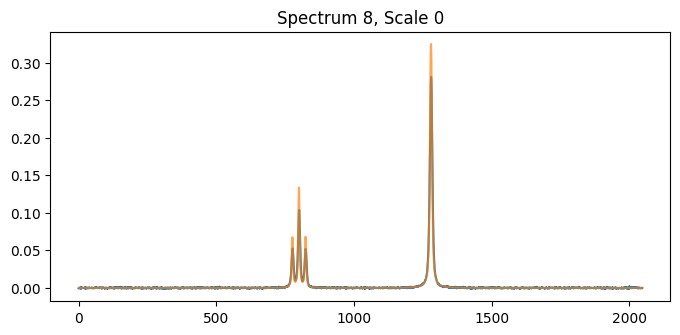

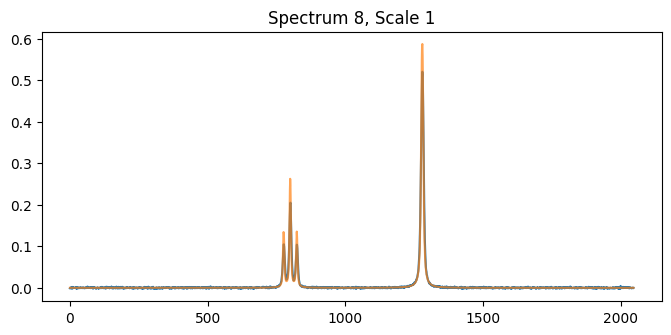

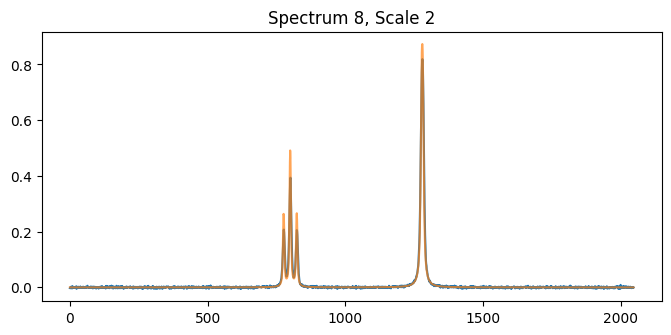

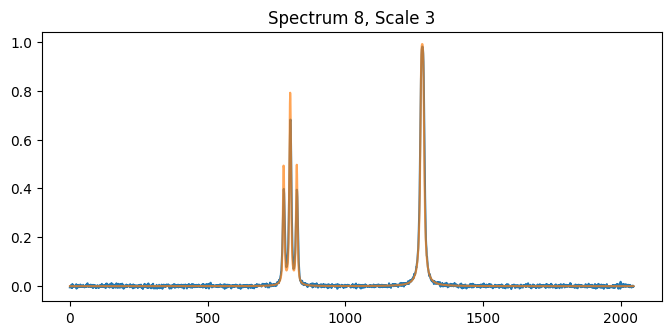

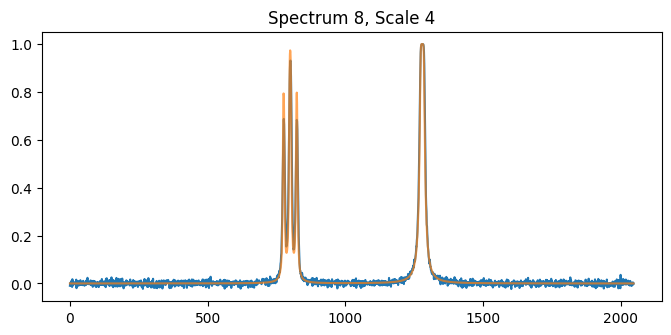

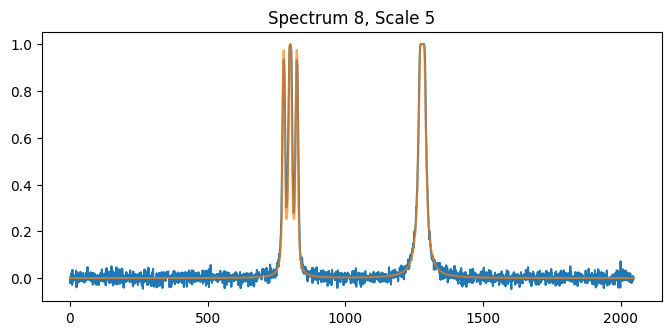

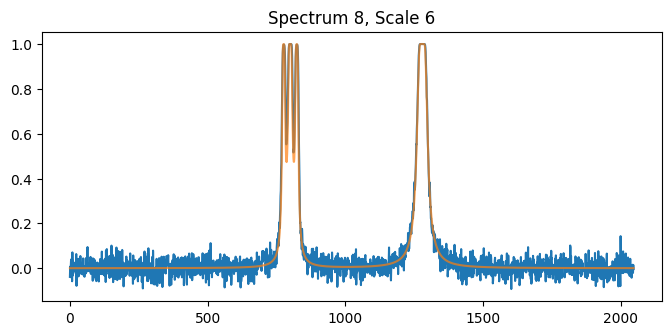

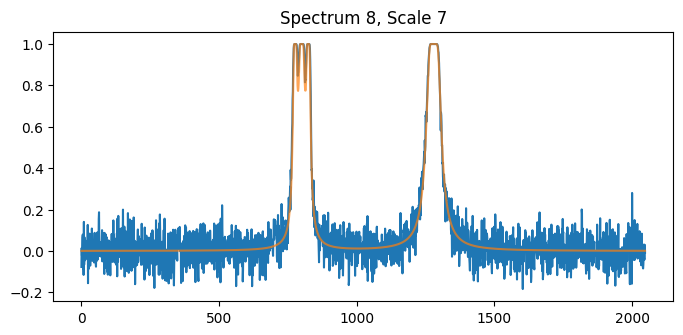

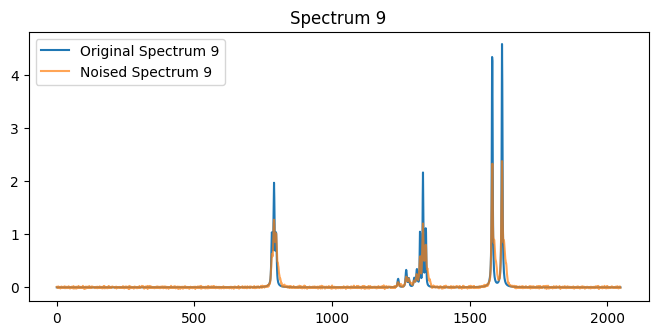

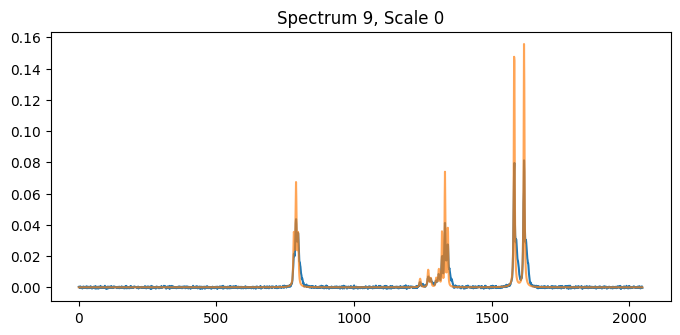

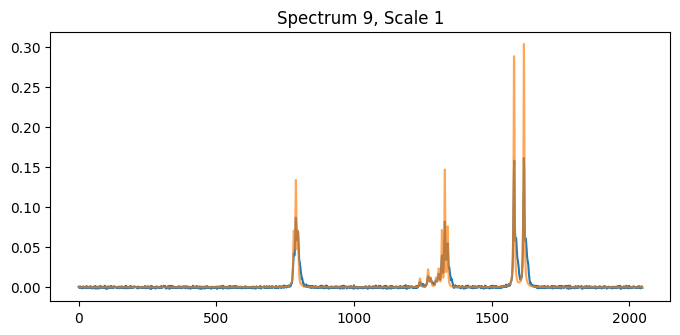

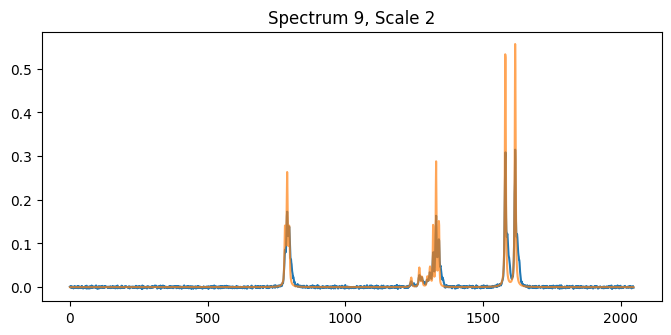

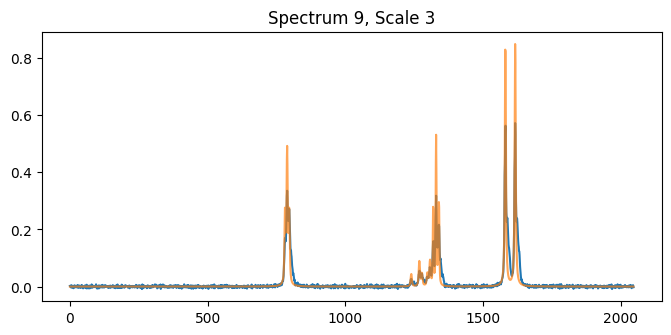

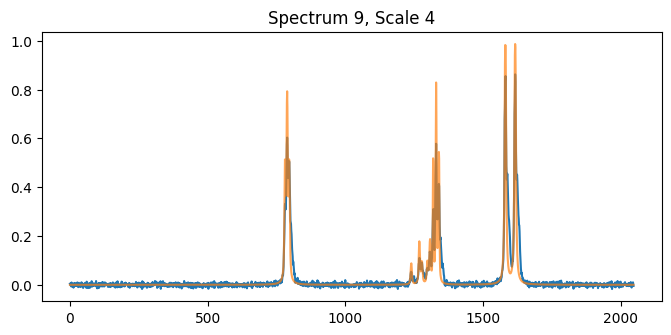

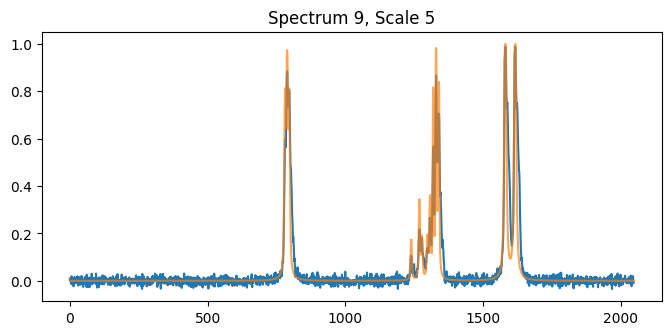

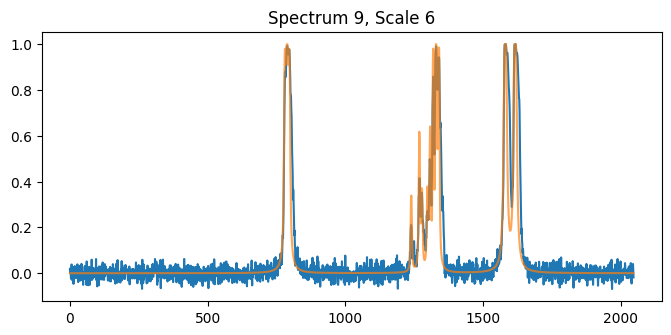

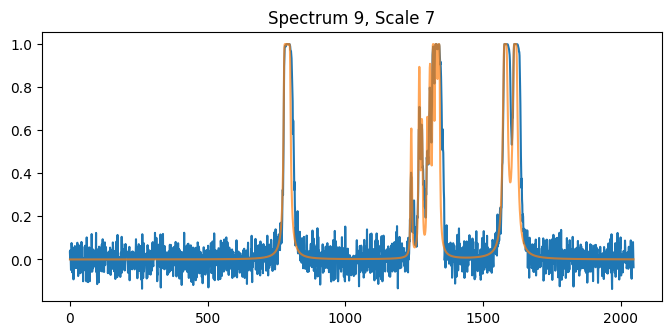

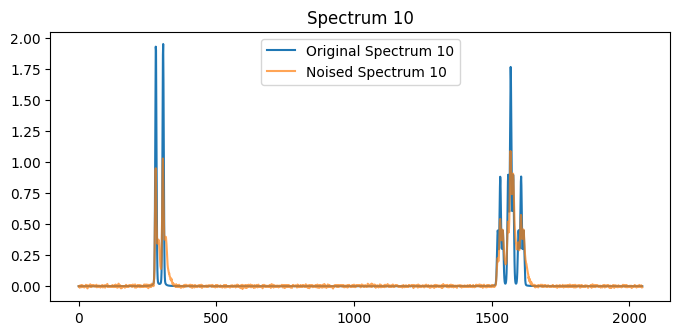

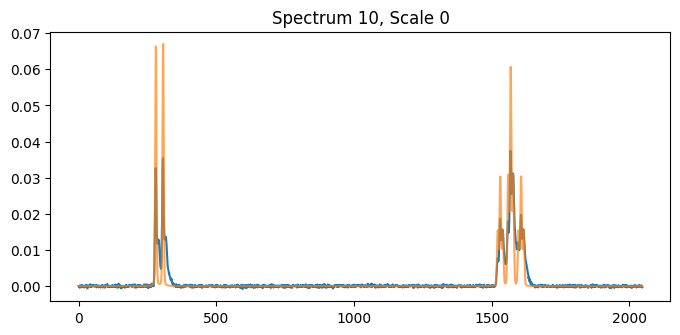

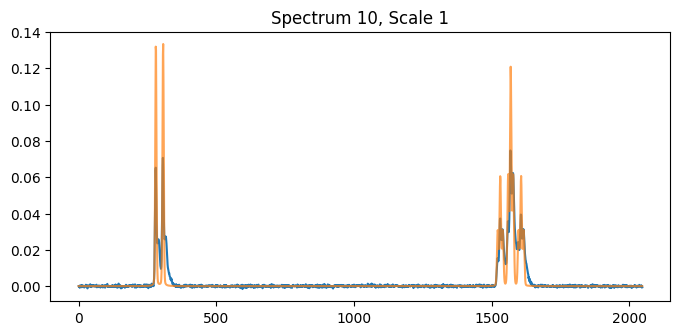

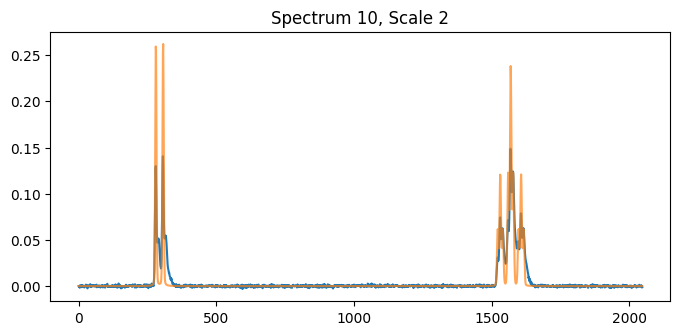

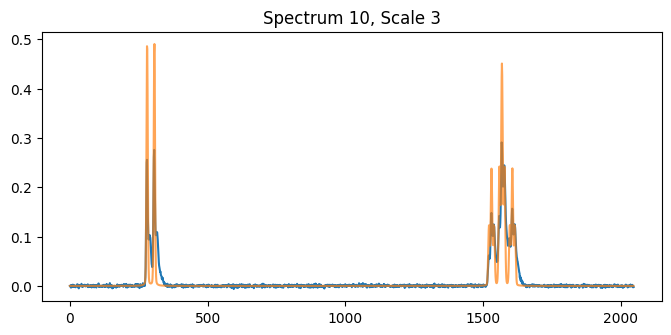

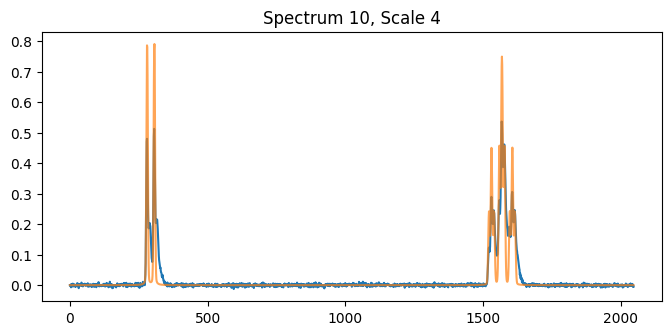

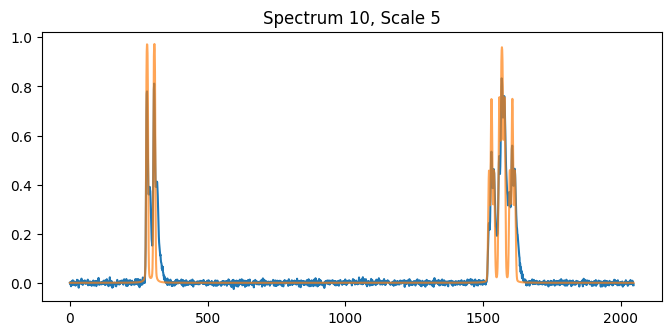

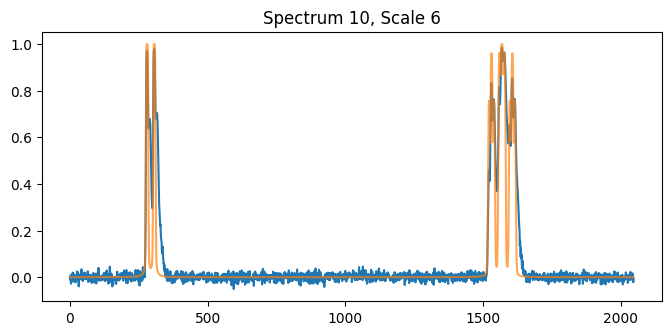

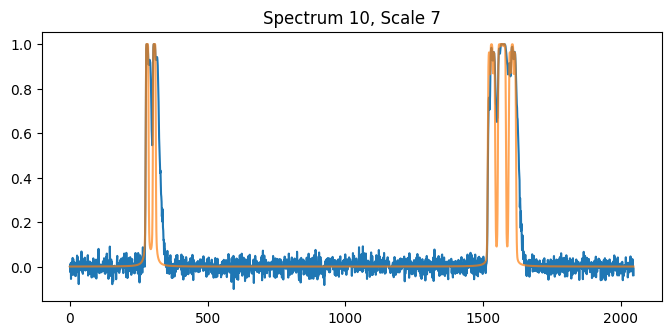

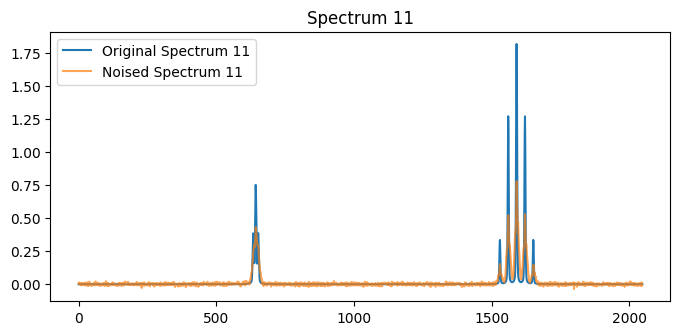

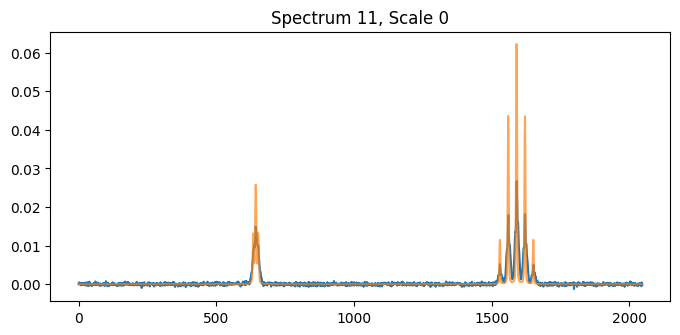

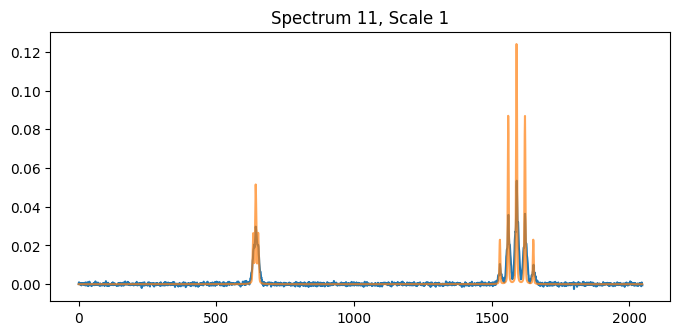

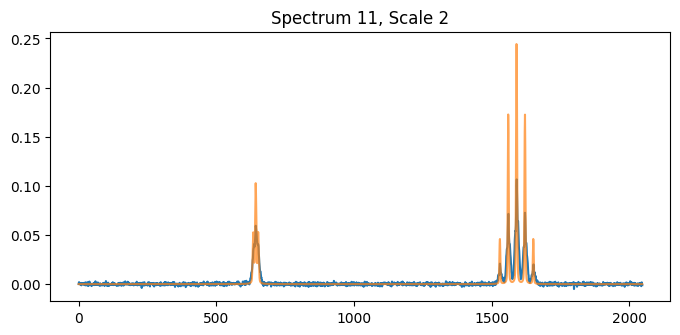

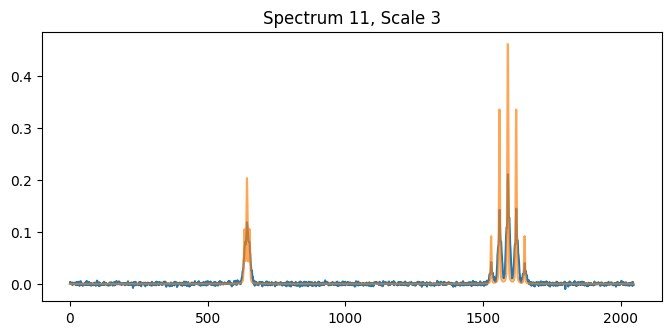

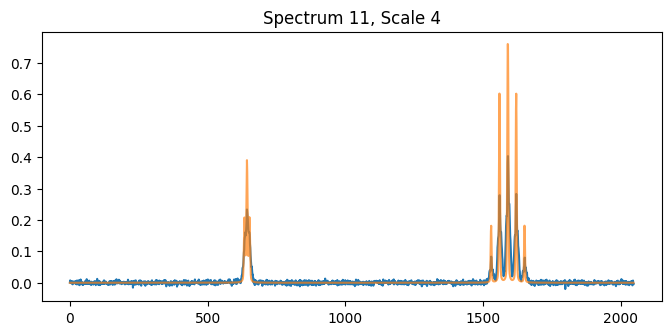

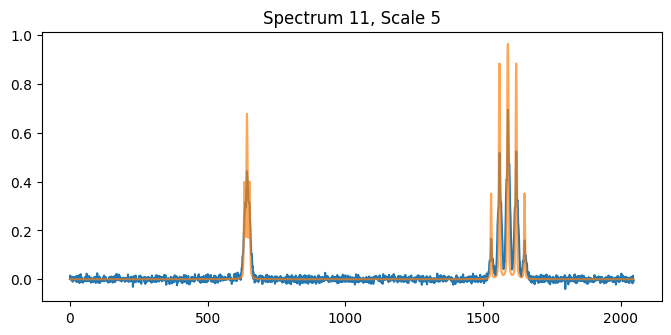

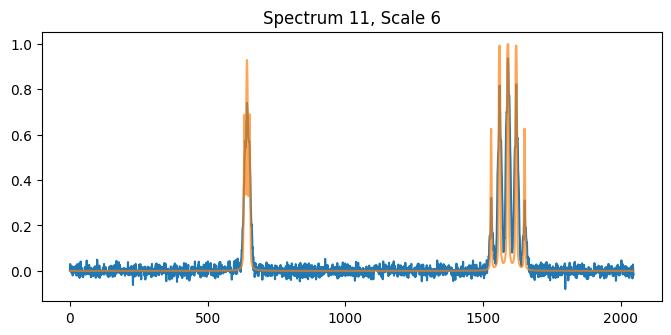

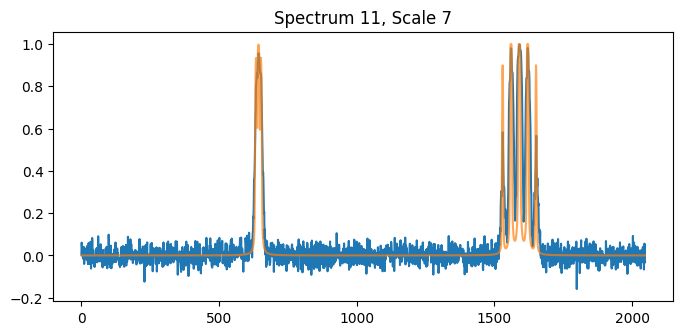

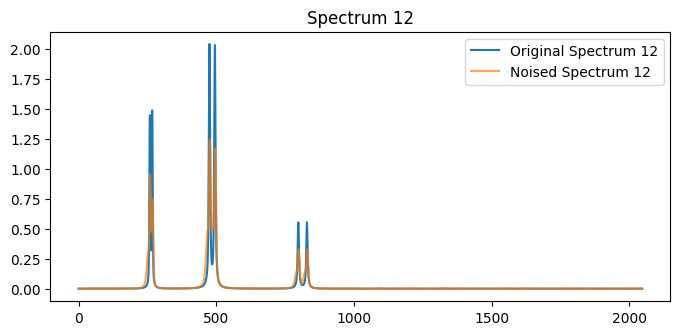

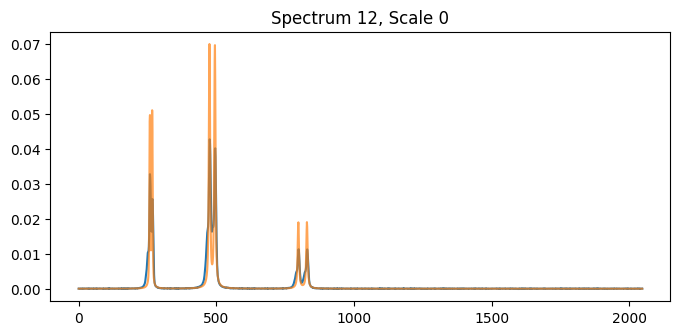

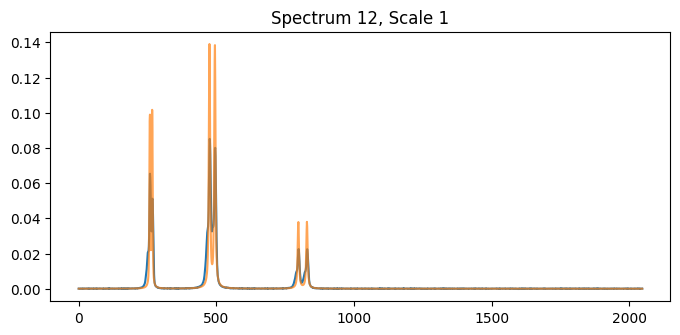

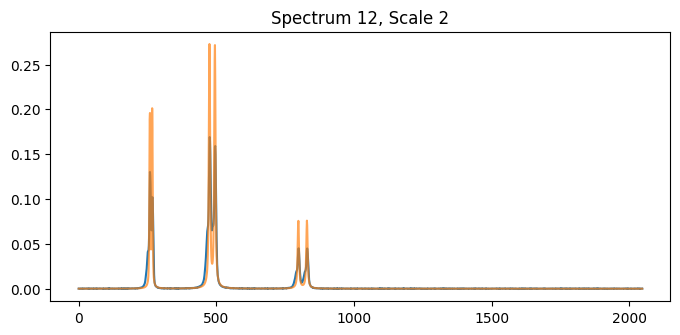

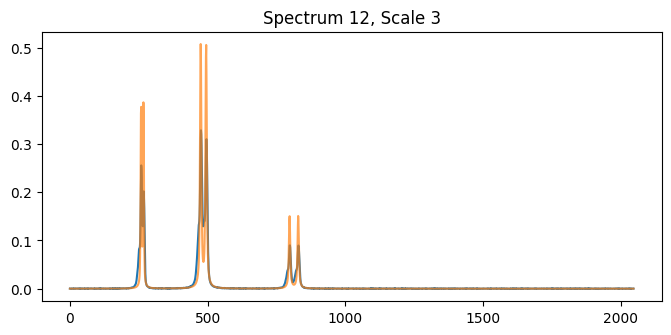

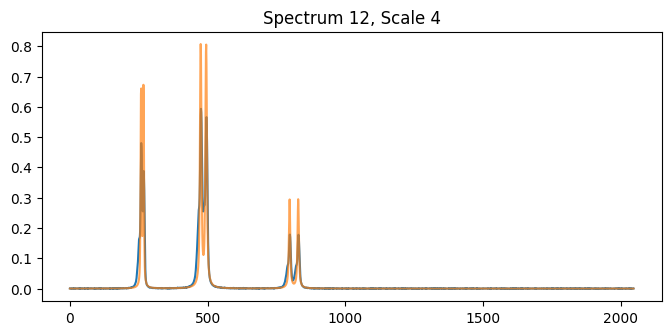

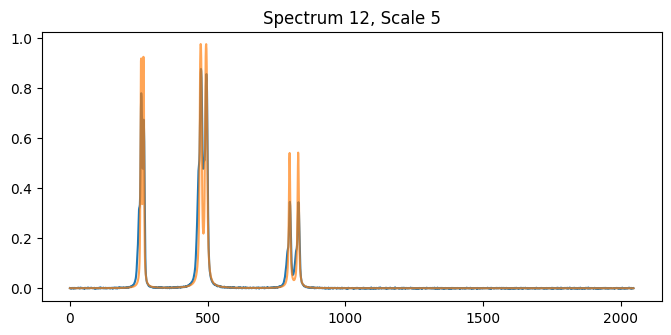

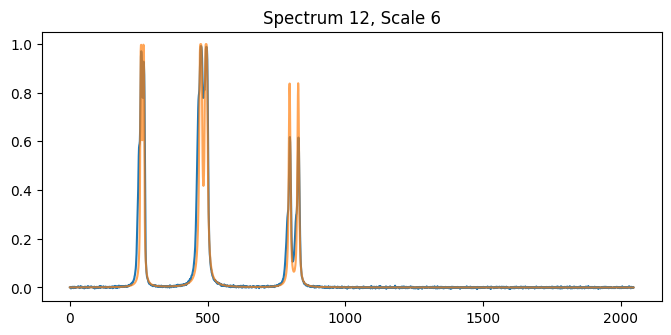

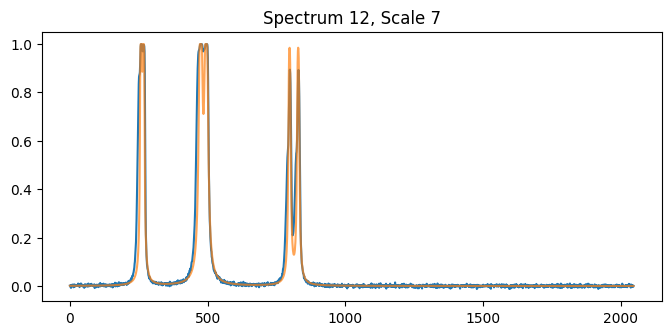

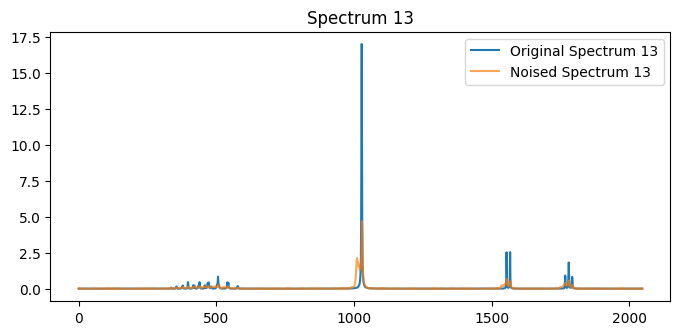

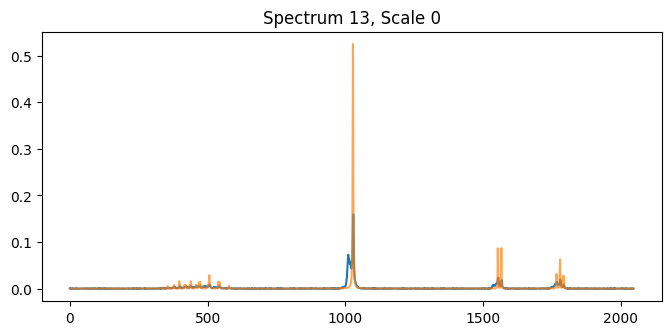

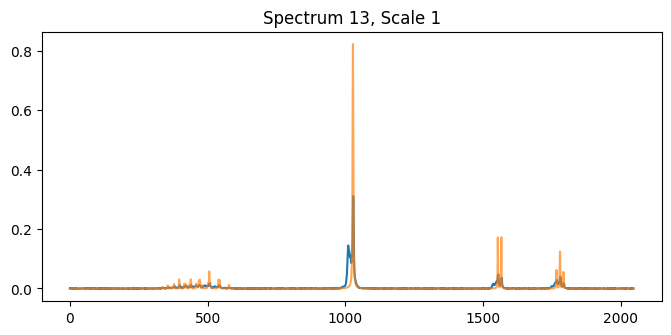

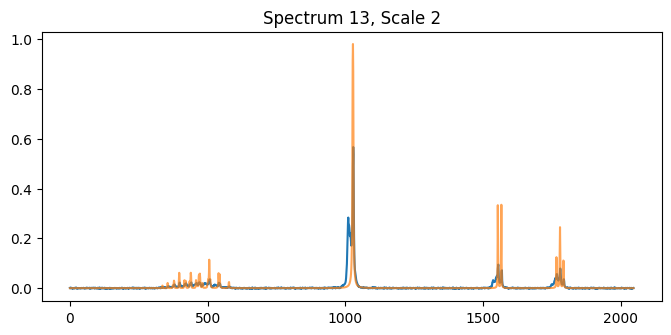

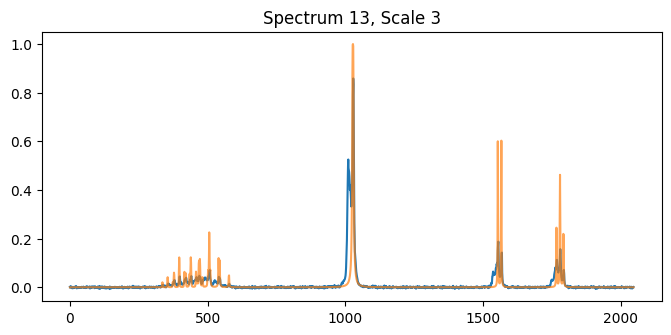

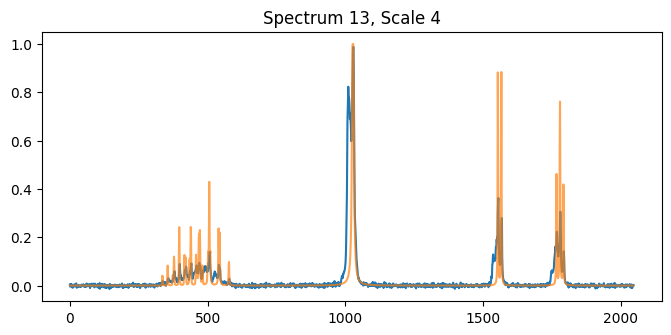

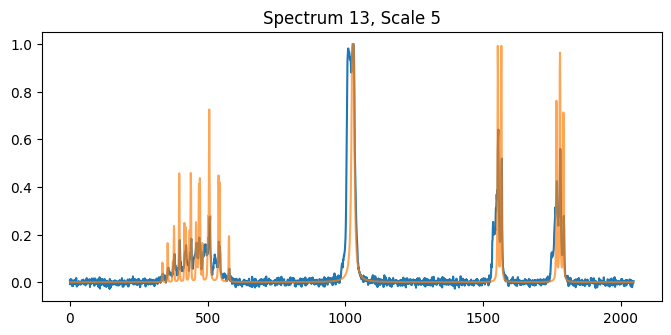

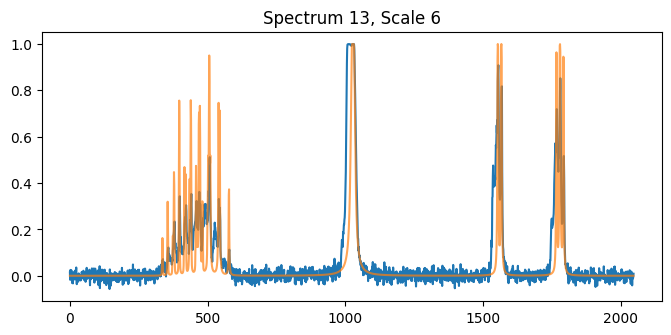

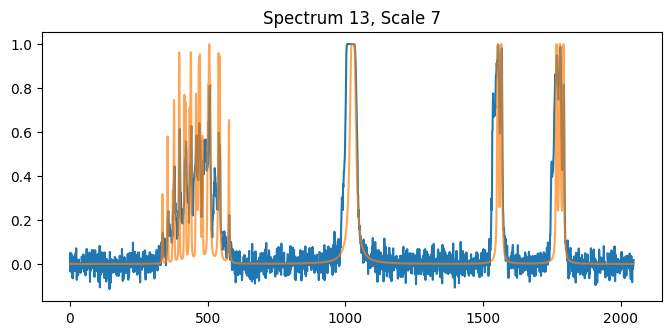

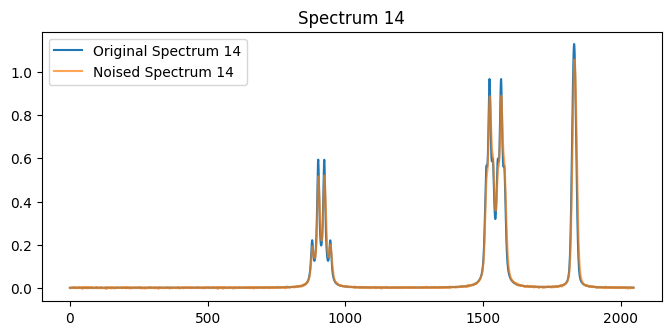

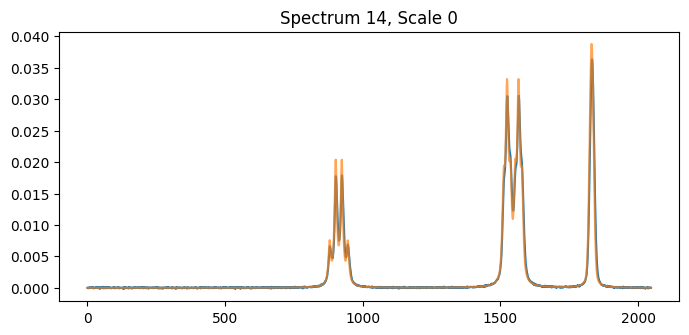

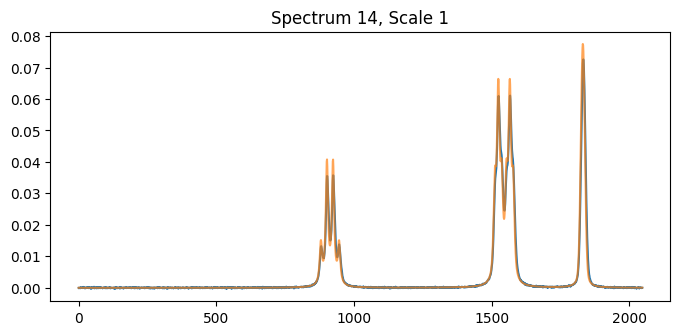

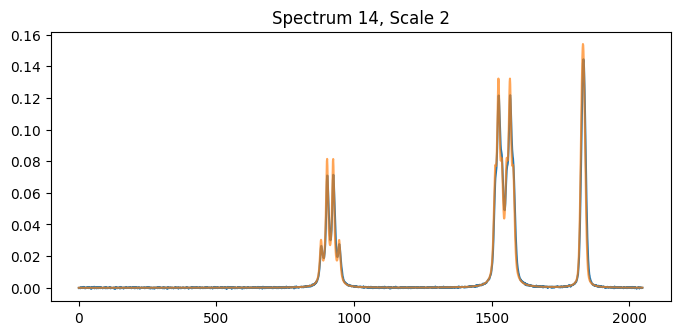

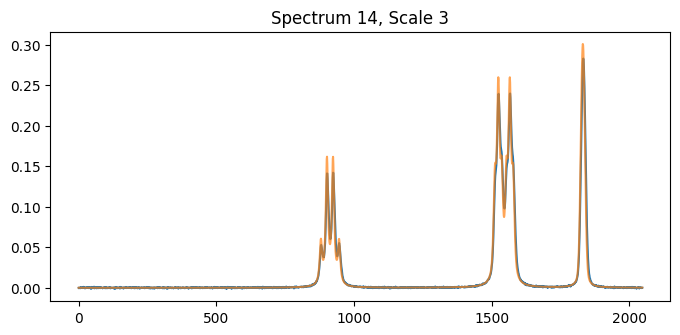

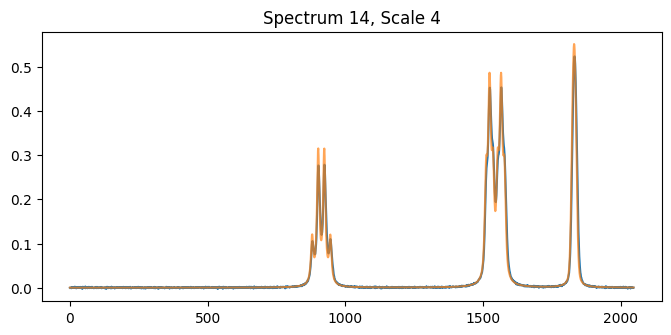

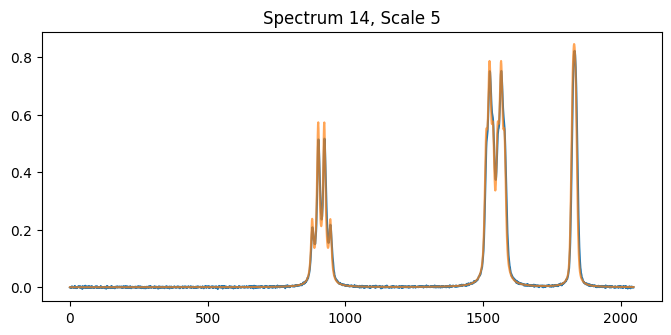

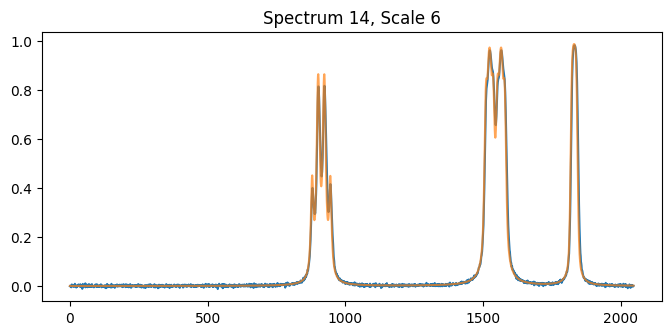

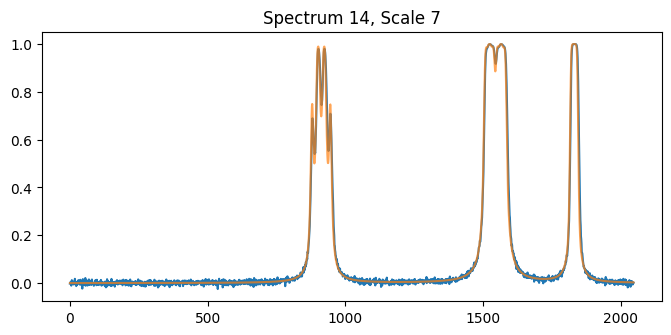

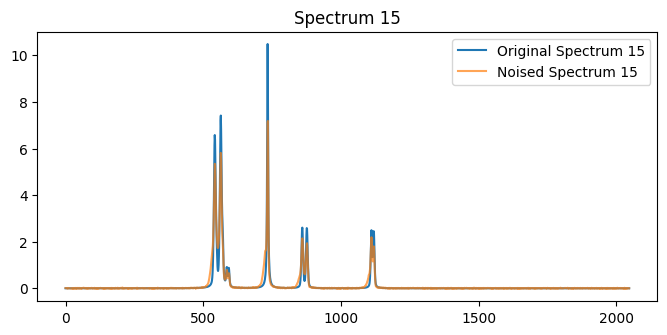

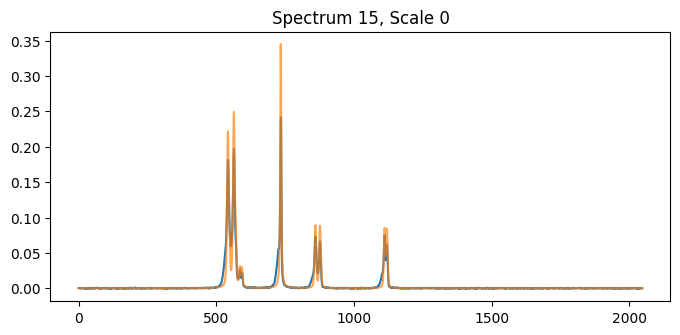

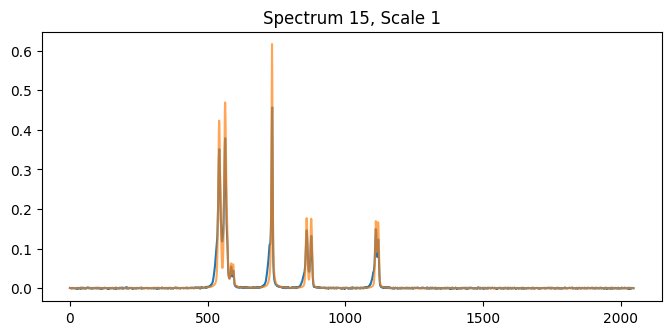

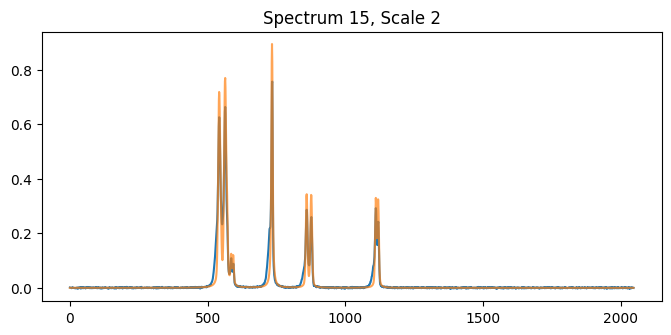

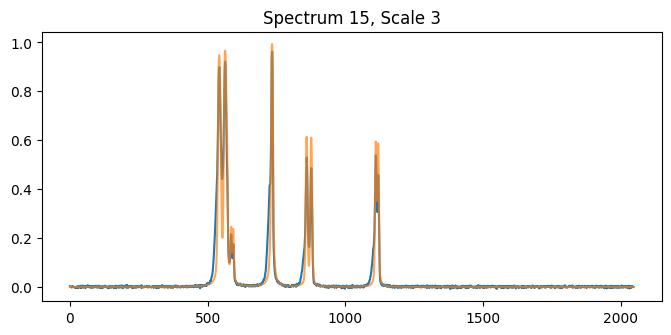

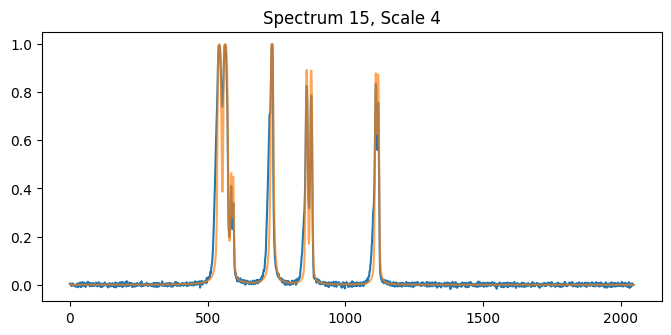

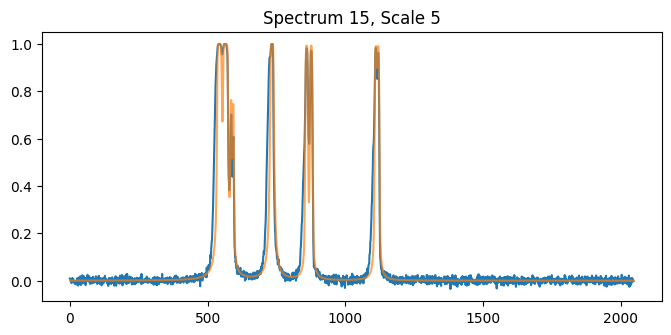

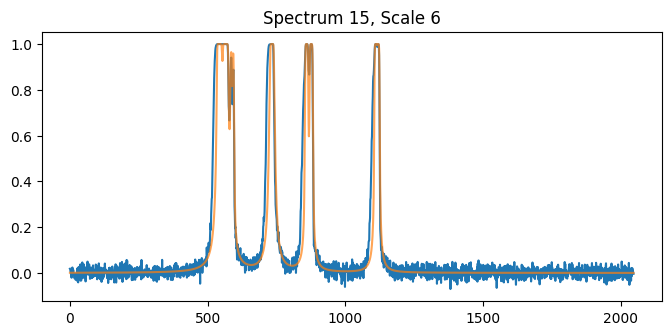

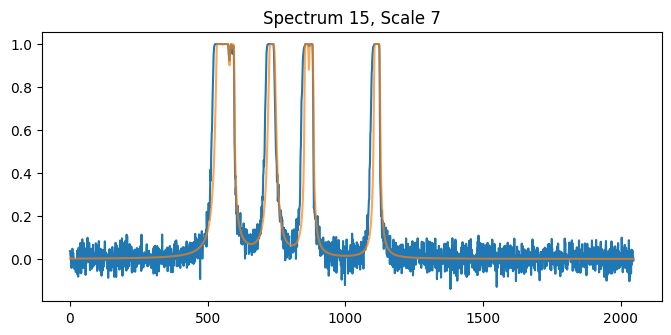

In [31]:
# spectrum_idx = 5
for spectrum_idx in range(batch["theoretical_spectrum"].shape[0]):
    plt.figure(figsize=(8,3.5))
    plt.plot(batch["theoretical_spectrum"][spectrum_idx,0].numpy(), label=f"Original Spectrum {spectrum_idx}")
    plt.plot(batch["noised_spectrum"][spectrum_idx,0].numpy(), label=f"Noised Spectrum {spectrum_idx}", alpha=0.7)
    plt.title(f"Spectrum {spectrum_idx}")
    plt.legend()

    for i in range(max(input_features.shape[1], output_features.shape[1])):
        plt.figure(figsize=(8,3.5))
        if i < input_features.shape[1]:
            plt.plot(input_features[spectrum_idx, i].numpy(), label=f"Scale {i}, input")
        if i < output_features.shape[1]:
            plt.plot(output_features[spectrum_idx, i].numpy(), label=f"Scale {i}, output", alpha=0.7)
        plt.title(f"Spectrum {spectrum_idx}, Scale {i}")